# UNO Card Detection — Test Inference

Loads the trained `uno_detector.pth` checkpoint and runs it over
`data/iapr-26-uno-vision-challenge/test_images`.

- No training. The checkpoint is assumed to already exist.
- Saves every detection (card label, score, bounding box, area tag)
  to a CSV — one row per detected card.
- Box coordinates are reported in the original 4000x2662 image space.
- Displays a few test images with all detections overlaid.

In [1]:
%reload_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import functional as F
from PIL import Image

import dl_dataset as ds

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} | device: {DEVICE}")

PyTorch 2.10.0+cu128 | device: cuda


## 1. Paths and constants

These must match the values used at training time.

In [2]:
TEST_DIR = Path('../data/iapr-26-uno-vision-challenge/test_images')
CHECKPOINT = Path('uno_detector.pth')
DETECTIONS_CSV = Path('test_detections.csv')

# Match training-time resize
CANVAS_W = 4000
CANVAS_H = 2662
TARGET_W = 800
TARGET_H = int(CANVAS_H * TARGET_W / CANVAS_W)

# Scale factors: model boxes are in TARGET space, we report them in CANVAS space
SCALE_X = CANVAS_W / TARGET_W
SCALE_Y = CANVAS_H / TARGET_H

SCORE_THRESH = 0.5  # min detection confidence kept in the CSV

test_images = sorted(TEST_DIR.glob('*.jpg')) + sorted(TEST_DIR.glob('*.jpeg'))
if not test_images:
    raise FileNotFoundError(f"No test images found in {TEST_DIR}")
if not CHECKPOINT.exists():
    raise FileNotFoundError(f"Missing checkpoint {CHECKPOINT}. Train UNO_dl.ipynb first.")

print(f"{len(test_images)} test images | checkpoint: {CHECKPOINT}")

159 test images | checkpoint: uno_detector.pth


## 2. Rebuild model and load checkpoint

In [3]:
num_classes = ds.NUM_CLASSES + 1  # +1 background
DROPOUT_P = 0.3

class FastRCNNPredictorDropout(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_p=DROPOUT_P):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout_p)
        self.cls_score = nn.Linear(in_channels, num_classes)
        self.bbox_pred = nn.Linear(in_channels, num_classes * 4)

    def forward(self, x):
        if x.dim() == 4:
            x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)
        return self.cls_score(x), self.bbox_pred(x)

model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(
    weights=None, weights_backbone=None,
)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictorDropout(in_features, num_classes)
model.transform.min_size = (TARGET_H,)
model.transform.max_size = TARGET_W

state = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(state)
model.to(DEVICE).eval()

idx_to_card = {i + 1: name for i, name in enumerate(ds.CARD_CLASSES)}
print(f"Model loaded ({num_classes} classes incl. background)")

Model loaded (55 classes incl. background)


## 3. Inference helpers

Run the detector and convert each kept detection into a CSV-ready row.
Boxes are rescaled to the original 4000x2662 image. The 5-area mapping
from `dl_dataset.get_area_crop` is kept as an `area` tag (`center`,
`p1`–`p4`, or `none`) so the dataframe is easy to filter later.

In [4]:
AREA_NAMES = {0: 'center', 1: 'p1', 2: 'p2', 3: 'p3', 4: 'p4'}


def area_for_point(cx: float, cy: float, w: int, h: int) -> int | None:
    """Return 0=center, 1=p1 (bottom), 2=p2 (right), 3=p3 (top), 4=p4 (left)."""
    if (w // 4) <= cx < (w * 3 // 4) and (h // 4) <= cy < (h * 3 // 4):
        return 0
    if (h // 2 + 300) <= cy < h and 900 <= cx < (w - 700):
        return 1
    if 0 <= cy < (h - 500) and (w - 1100) <= cx < w:
        return 2
    if 0 <= cy < (h // 2 - 300) and 900 <= cx < (w - 900):
        return 3
    if 600 <= cy < (h - 300) and 0 <= cx < (w // 2 - 600):
        return 4
    return None


@torch.no_grad()
def predict_image(img_path: Path):
    """Run the detector on one image.

    Returns (resized_image, boxes, labels, scores) with boxes in the
    resized (TARGET_W x TARGET_H) coordinate space.
    """
    img = Image.open(img_path).convert('RGB').resize(
        (TARGET_W, TARGET_H), resample=Image.BILINEAR
    )
    tensor = F.to_tensor(img).to(DEVICE)
    pred = model([tensor])[0]
    return (
        img,
        pred['boxes'].detach().cpu().numpy(),
        pred['labels'].detach().cpu().numpy(),
        pred['scores'].detach().cpu().numpy(),
    )


def detection_rows(img_path: Path, boxes, labels, scores, score_thresh=SCORE_THRESH):
    """Yield one dict per kept detection, with boxes in CANVAS (4000x2662) space."""
    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        card = idx_to_card.get(int(label))
        if card is None:
            continue
        x1, y1, x2, y2 = box
        cx, cy = 0.5 * (x1 + x2), 0.5 * (y1 + y2)
        a = area_for_point(cx, cy, TARGET_W, TARGET_H)
        yield {
            'image_id': img_path.stem,
            'card': card,
            'score': float(score),
            'x1': float(x1 * SCALE_X),
            'y1': float(y1 * SCALE_Y),
            'x2': float(x2 * SCALE_X),
            'y2': float(y2 * SCALE_Y),
            'cx': float(cx * SCALE_X),
            'cy': float(cy * SCALE_Y),
            'area': AREA_NAMES.get(a, 'none'),
        }

## 4. Run on all test images and save per-detection CSV

The CSV has one row per detected card with columns:
`image_id, card, score, x1, y1, x2, y2, cx, cy, area`.
Coordinates are in the original 4000x2662 image.

In [5]:
rows = []
for img_path in test_images:
    _, boxes, labels, scores = predict_image(img_path)
    rows.extend(detection_rows(img_path, boxes, labels, scores))

detections = pd.DataFrame(rows, columns=[
    'image_id', 'card', 'score', 'x1', 'y1', 'x2', 'y2', 'cx', 'cy', 'area',
])
detections.to_csv(DETECTIONS_CSV, index=False)
print(f"Wrote {len(detections)} detections across "
      f"{detections['image_id'].nunique()} images to {DETECTIONS_CSV.resolve()}")
detections.head(10)

Wrote 1204 detections across 159 images to /home/paul/Documents/EPFL/Cours/IAPR/Image_Analysis_lab/labs/test_detections.csv


,image_id,card,score,x1,y1,x2,y2,cx,cy,area
0,L1000793,r_9,0.999447,2208.962158,128.895416,2659.156494,755.979065,2434.059570,442.437256,none
1,L1000793,b_6,0.997226,1341.191895,116.586670,1745.589478,709.966064,1543.390625,413.276398,none
2,L1000793,g_0,0.995997,1740.920410,1312.521484,2309.937500,1722.106812,2025.428955,1517.314087,center
3,L1000793,g_4,0.992491,3194.117676,1764.330322,3770.597900,2181.589844,3482.357910,1972.960083,none
4,L1000793,g_8,0.989584,83.683968,1456.423462,648.554077,1865.470093,366.119019,1660.946777,none
5,L1000793,y_5,0.979796,1803.606567,92.280289,2203.930664,695.596130,2003.768555,393.938232,none
6,L1000793,y_5,0.950926,61.807747,1034.464844,637.200500,1508.611816,349.504120,1271.538330,none
7,L1000793,r_5,0.924178,97.181488,603.264099,657.231934,1015.836426,377.206696,809.550232,none
8,L1000793,r_9,0.915762,3197.508301,882.952637,3779.703125,1294.674927,3488.605713,1088.813843,none
9,L1000793,r_6,0.838465,3186.135010,1369.898438,3754.640869,1752.491089,3470.387939,1561.194824,none


## 5. Visualise predictions on a few test images

All kept detections are drawn (regardless of area). Colour denotes the
area each box was assigned to (`none` for boxes outside every area).

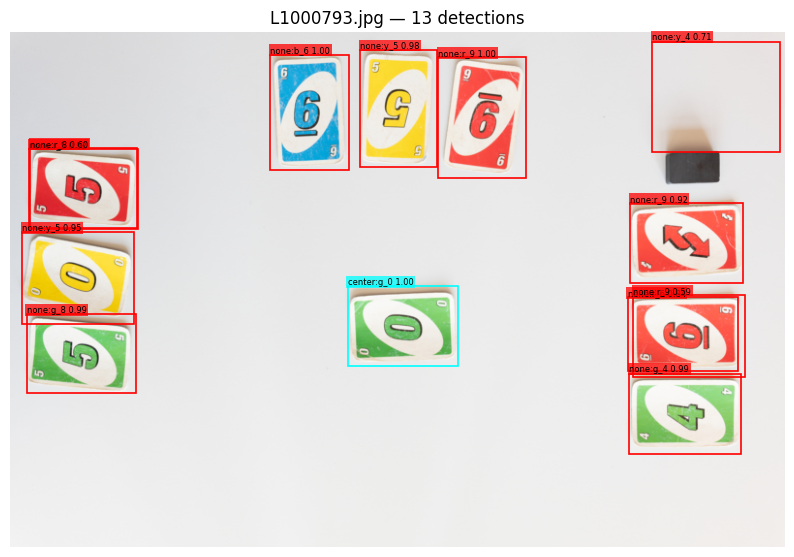

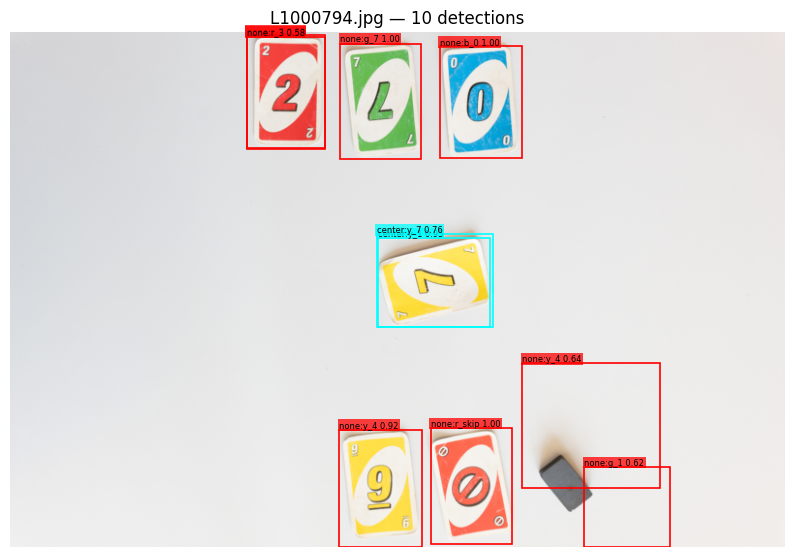

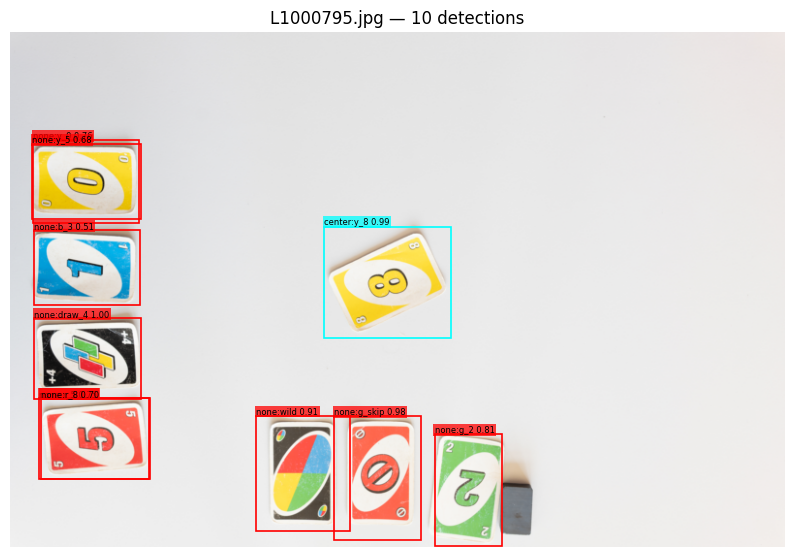

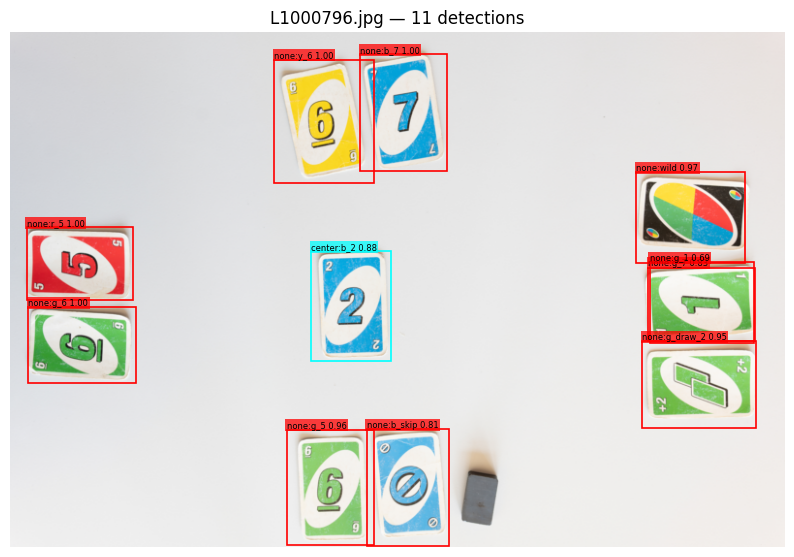

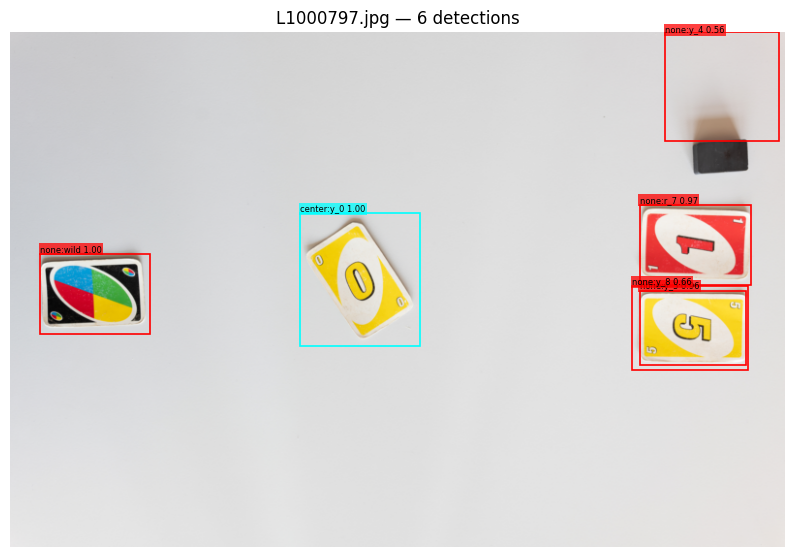

In [6]:
AREA_COLORS = {
    'center': 'cyan',
    'p1': 'lime',
    'p2': 'magenta',
    'p3': 'yellow',
    'p4': 'orange',
    'none': 'red',
}


def show_test_prediction(img_path: Path, score_thresh: float = SCORE_THRESH):
    img, boxes, labels, scores = predict_image(img_path)
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(img)
    n_kept = 0
    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue
        card = idx_to_card.get(int(label), '?')
        x1, y1, x2, y2 = box
        cx, cy = 0.5 * (x1 + x2), 0.5 * (y1 + y2)
        a = area_for_point(cx, cy, TARGET_W, TARGET_H)
        area_name = AREA_NAMES.get(a, 'none')
        color = AREA_COLORS[area_name]
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.2, edgecolor=color, facecolor='none',
        ))
        ax.text(
            x1, max(0, y1 - 2), f"{area_name}:{card} {score:.2f}",
            color='black', fontsize=6,
            bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor='none'),
        )
        n_kept += 1
    ax.set_title(f"{img_path.name} — {n_kept} detections")
    ax.axis('off')
    plt.show()


for p in test_images[:5]:
    show_test_prediction(p)